# Simulation Study

In this Jupyter Notebook, the simulation study of the Masterthesis "Regression for Large Matrices with Joint Column and Row Reduction is performed.
Therefore, the following steps are covered:
- Importing required packages and functions
- Data Loading
- Application of Scoring Mechanisms such as Leverage Scores, Cross Leverage Scores, Random Scores and combined Scores
- Application of Column Reduction
- Application of Row Reduction
- Regression using linear models
- Evaluation of models and scoring mechanisms

In [211]:
#==============================================================================================
# Packages: Import of required packages for the simulation study
#==============================================================================================
%load_ext autoreload
%autoreload 2

import pandas as pd
from pathlib import Path
import random
from functions import get_leverage_scores, get_cross_leverage_scores, get_random_scores, get_combined_scores, \
    row_reduction, column_reduction
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from plotnine import ggplot, aes, geom_histogram, theme_bw, labs, geom_line, theme_minimal, geom_boxplot
from IPython.display import display

base = Path("/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/Simulation Data")
folder = "p1000_n900"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [212]:
#==============================================================================================
# Data Loading: Import the simulated data sets from corresponding folders
#==============================================================================================

## initialize lists to store data
df_train = []
df_test = []
y_train = []
y_test = []

## read in the simulation data
for i in range(10):
    df_train.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/X_train.csv")
    )
    df_test.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/X_test.csv")
    )
    y_train.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/y_train.csv")
    )
    y_test.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/y_test.csv")
    )

print("Shape of Training Data: ", np.shape(df_train[0]))
df_train[0].head()

Shape of Training Data:  (720, 1000)


,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,0.48940763,-1.3365464,-1.1138309,-0.4529517,1.6798241,-1.0300092,2.4265904,0.036485665,-0.9186341,-1.138299,...,1.0622252,0.27532765,0.78732353,0.17963603,-1.0355898,-0.019407177,-0.7403436,-1.9321772,1.1586596,-0.39525935
1,-0.95737004,0.045942705,-0.772199,1.0898916,-1.5788925,-0.95179075,-0.30889553,0.9685488,1.6352783,0.14434673,...,0.9248747,1.2113984,-1.2162019,-0.00029110722,1.9223812,-0.98204535,-1.3869884,-1.4774071,0.031359687,-0.13555853
2,-1.6415124,-2.3851411,1.4885222,-0.5683536,0.6096026,-0.3897477,1.7956898,-2.2578754,-0.4421387,0.15759848,...,-0.19137459,0.46999124,-1.6077456,0.72388417,-0.82483006,-0.7092231,-0.32290763,1.1495969,-0.968917,-0.16925187
3,0.9733367,-0.24864665,1.1663989,-0.9174811,0.9850009,-0.25291964,1.6127403,-1.3349732,-0.12970851,0.8061096,...,-1.0790758,0.0062031955,-0.114922,0.95770645,1.0548818,0.44111162,-0.304699,0.80287564,-1.439379,-1.5027109
4,0.58487713,-2.3099463,-0.095216036,-0.24510498,-0.9888419,1.0235603,0.6145533,0.027057976,-0.5657045,-1.6955075,...,1.3870474,1.6727191,-0.42102033,0.4229156,0.4812275,0.6687485,0.037214383,0.37430185,0.09666948,-1.3065377


In [213]:
#==============================================================================================
# Parameter Setting: Set the rank parameter and the seed of the script for reproducibility
#==============================================================================================

## set the seed
random.seed(1)

## set the basis parameters
k = 75
c = np.ceil(k * np.log(k))
r = np.ceil(c * np.log(c))

print("c = ", c)
print("r = ", r)

c =  324.0
r =  1873.0


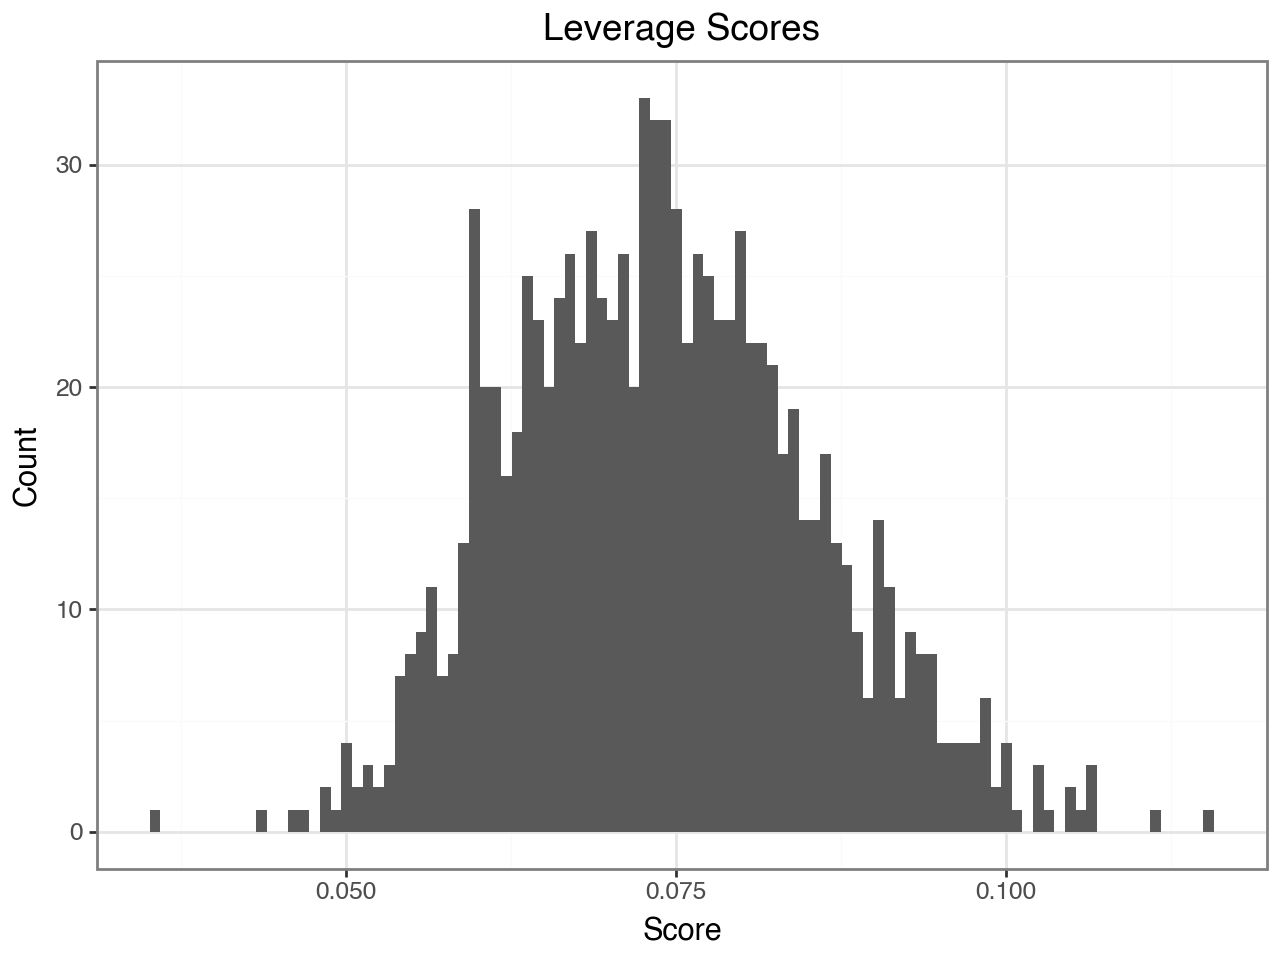

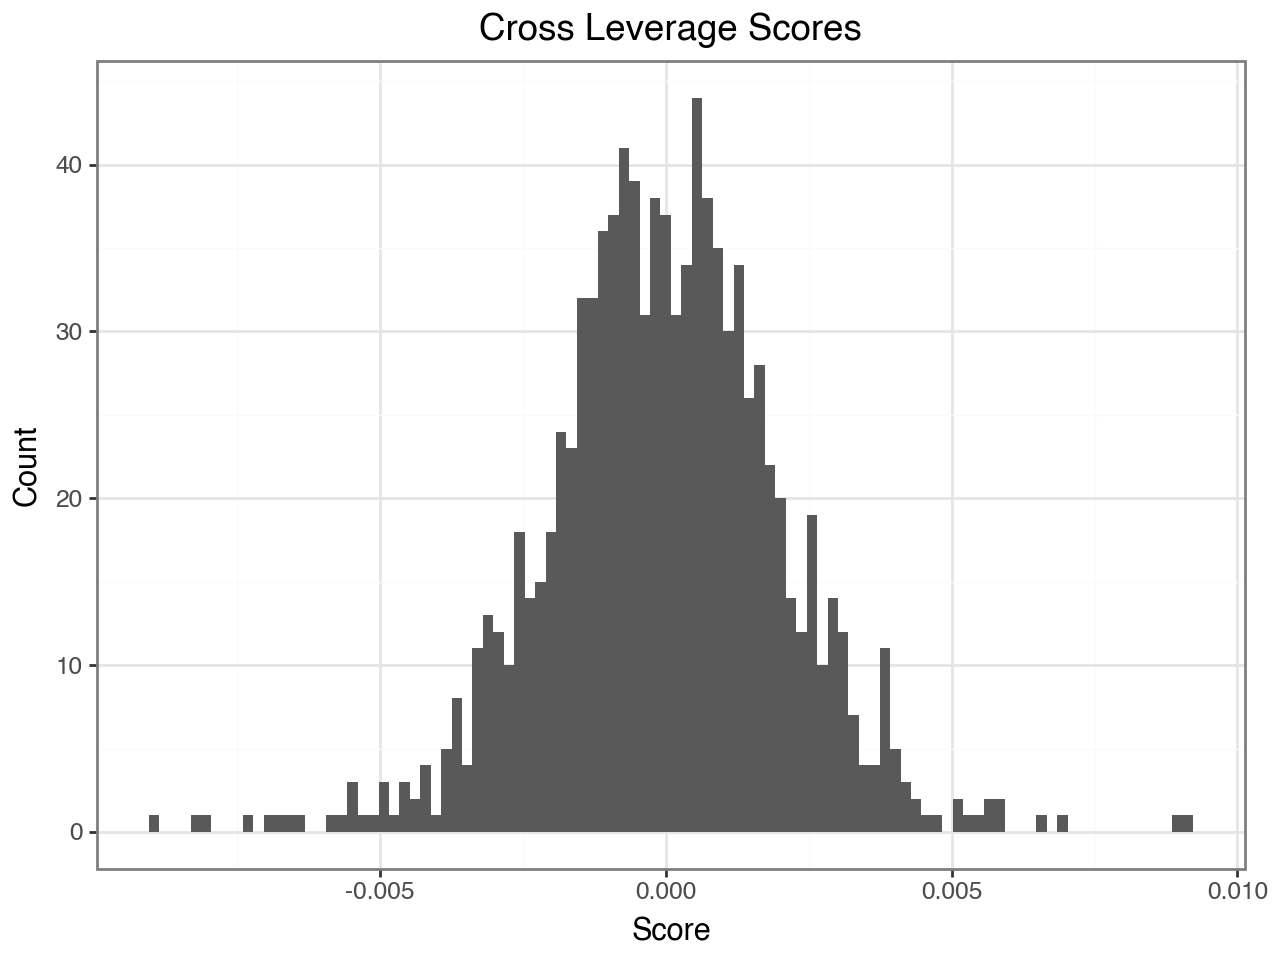

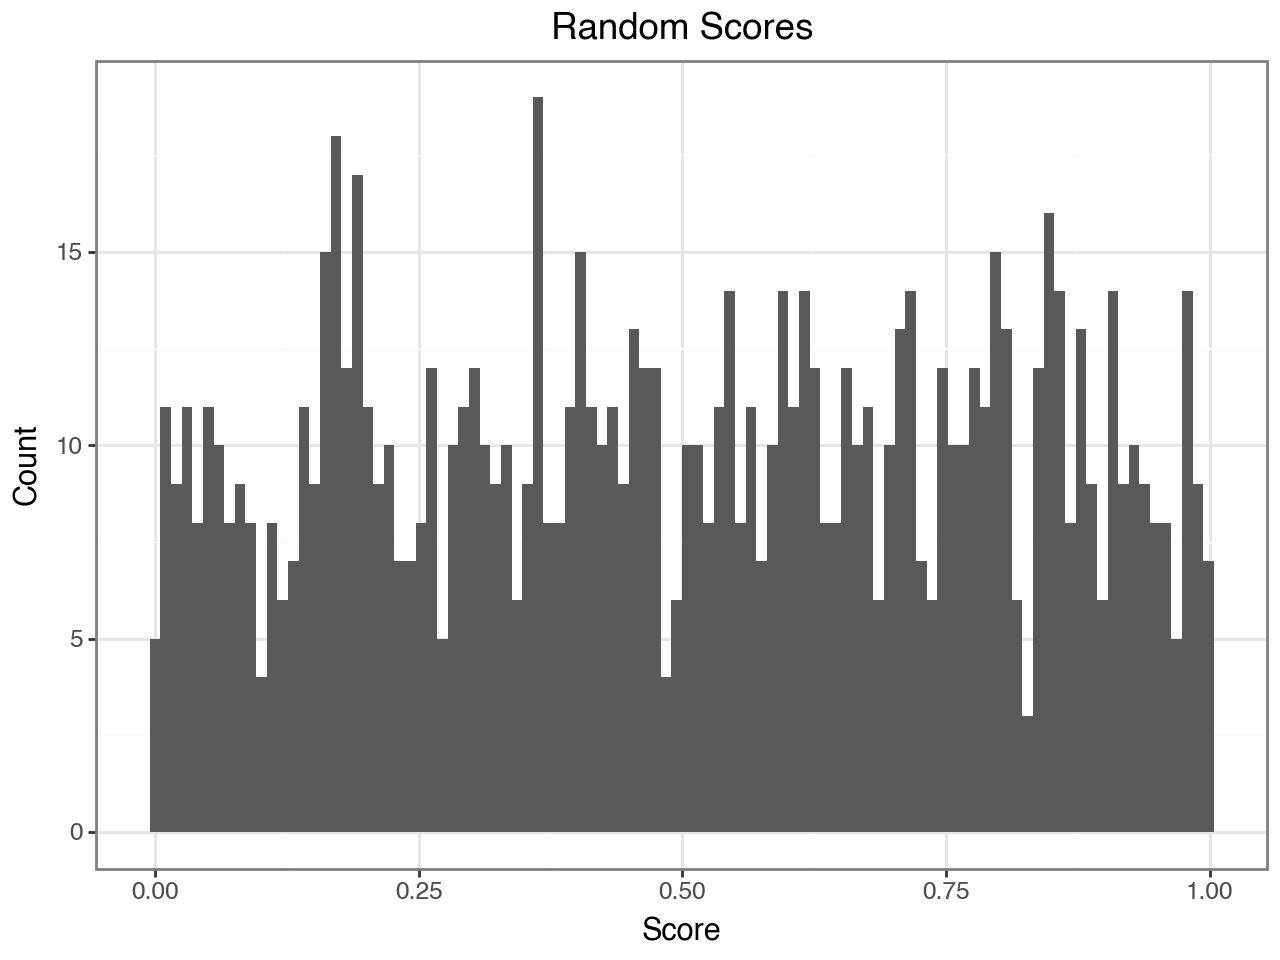

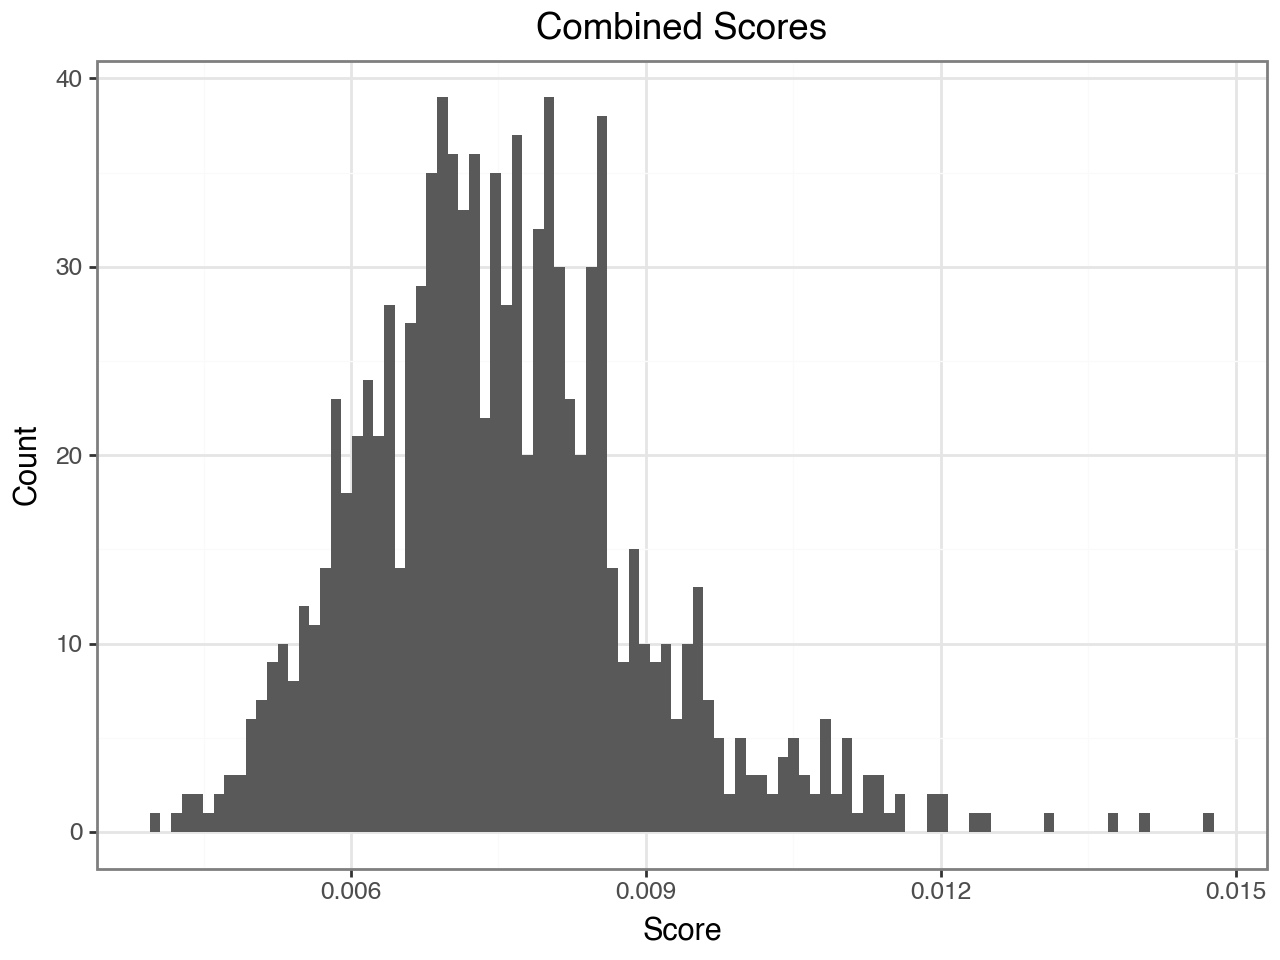

In [214]:
#==============================================================================================
# Scoring Mechanisms: Application of different scoring functions to the training data
#==============================================================================================

## Calculate the scores per data frame
column_ls = []
column_cls = []
column_rs = []
column_cs = []

for i in range(10):
    column_ls.append(get_leverage_scores(df_train[i], k))
    column_cls.append(get_cross_leverage_scores(df_train[i], y_train[i]))
    column_rs.append(get_random_scores(df_train[i]))
    column_cs.append(get_combined_scores(df_train[i], y_train[i], k, p_leverage = 0.2))

## Investigation of distributions
df_ls  = pd.DataFrame({'value': column_ls[0]})
df_cls = pd.DataFrame({'value': column_cls[0]})
df_rs  = pd.DataFrame({'value': column_rs[0]})
df_cs  = pd.DataFrame({'value': column_cs[0]})

display(
    ggplot(df_ls, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Leverage Scores', x='Score', y='Count')
)

display(
    ggplot(df_cls, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Cross Leverage Scores', x='Score', y='Count')
)

display(
    ggplot(df_rs, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Random Scores', x='Score', y='Count')
)

display(
    ggplot(df_cs, aes(x='value'))
    + geom_histogram(bins=100)
    + theme_bw()
    + labs(title='Combined Scores', x='Score', y='Count')
)

In [215]:
#==============================================================================================
# Column Reduction: Application of column reduction mechanism
#==============================================================================================

## Calculation of column reduction
C_ls = []
C_cls = []
C_rs = []
C_cs = []

for i in range(10):
    C_ls.append(column_reduction(df_train[i], column_ls[i], k))
    C_cls.append(column_reduction(df_train[i], np.abs(column_cls[i]), k))
    C_rs.append(column_reduction(df_train[i], column_rs[i], k))
    C_cs.append(column_reduction(df_train[i], column_cs[i], k))

In [216]:
#==============================================================================================
# Row Reduction: Application of row reduction mechanism
#==============================================================================================

## Calculation of row reduction
R_ls = []
R_cls = []
R_rs = []
R_cs = []

for i in range(10):
    R_ls.append(row_reduction(C_ls[i]['C'], y_train[i], k))
    R_cls.append(row_reduction(C_cls[i]['C'], y_train[i], k))
    R_rs.append(row_reduction(C_rs[i]['C'], y_train[i], k))
    R_cs.append(row_reduction(C_cs[i]['C'], y_train[i], k))

This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getting transposed.
No row reduction needed. Original Matrix C kept.
This function is designed for the case n < p. The matrix is now getti

In [217]:
#==============================================================================================
# Linear Modeling: Application of linear model to reduced data sets, and RMSE calculations
#==============================================================================================

## Fit linear models to the reduced data matrix
model_ls = []
model_cls = []
model_rs = []
model_cs = []
for i in range(10):
    model = LinearRegression()
    model.fit(R_ls[i]['R'], R_ls[i]['y'])
    model_ls.append(model)
    model = LinearRegression()
    model.fit(R_cls[i]['R'], R_cls[i]['y'])
    model_cls.append(model)
    model = LinearRegression()
    model.fit(R_rs[i]['R'], R_rs[i]['y'])
    model_rs.append(model)
    model = LinearRegression()
    model.fit(R_cs[i]['R'], R_cs[i]['y'])
    model_cs.append(model)

## Build predictions
predictions_ls = []
predictions_cls = []
predictions_rs = []
predictions_cs = []
df_test_reduced_ls = []
df_test_reduced_cls = []
df_test_reduced_rs = []
df_test_reduced_cs = []
for i in range(10):
    df_test_reduced_ls.append(df_test[i].iloc[:, C_ls[i]['selected_columns']])
    predictions_ls.append(model_ls[i].predict(df_test_reduced_ls[i]))
    df_test_reduced_cls.append(df_test[i].iloc[:, C_cls[i]['selected_columns']])
    predictions_cls.append(model_cls[i].predict(df_test_reduced_cls[i]))
    df_test_reduced_rs.append(df_test[i].iloc[:, C_rs[i]['selected_columns']])
    predictions_rs.append(model_rs[i].predict(df_test_reduced_rs[i]))
    df_test_reduced_cs.append(df_test[i].iloc[:, C_cs[i]['selected_columns']])
    predictions_cs.append(model_cs[i].predict(df_test_reduced_cs[i]))

## Calculate RMSE
rmse_ls = []
rmse_cls = []
rmse_rs = []
rmse_cs = []
for i in range(10):
    rmse_ls.append(np.sqrt(mean_squared_error(y_test[i], predictions_ls[i])))
    rmse_cls.append(np.sqrt(mean_squared_error(y_test[i], predictions_cls[i])))
    rmse_rs.append(np.sqrt(mean_squared_error(y_test[i], predictions_rs[i])))
    rmse_cs.append(np.sqrt(mean_squared_error(y_test[i], predictions_cs[i])))

/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester/Masterarbeit/Masterthesis/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
/Users/timschmale/Library/Mobile Documents/com~apple~CloudDocs/Documents/Studium/Data Science/Master/5. Semester

In [218]:
#==============================================================================================
# Full Model: Application of Linear Model to the optimal set of columns
#==============================================================================================
beta_train = []
rmse_full = []
for i in range(10):
    beta_train.append(
        pd.read_csv(f"{base}/{folder}/rep{i+1}/beta.csv")
    )
    beta = np.array(beta_train[i])
    selected_cols = np.where(beta != 0)[0]

    # Train Data Reduction
    X_train_sel = df_train[i].iloc[:, selected_cols]
    X_test_sel = df_test[i].iloc[:, selected_cols]

    # make sure its 1D
    y_tr = np.ravel(y_train[i])
    y_te = np.ravel(y_test[i])

    # Model fit
    model = LinearRegression()
    model.fit(X_train_sel, y_tr)

    # predict
    predictions = model.predict(X_test_sel)

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_te, predictions))
    rmse_full.append(rmse)

rmse_df = pd.DataFrame({
    "LS": rmse_ls,
    "CLS": rmse_cls,
    "Combined": rmse_cs,
    "Random": rmse_rs,
    "Full": rmse_full
})
print(rmse_full)


[np.float64(7.279001024658607), np.float64(8.99845180299931), np.float64(7.811001384722859), np.float64(9.278763325082894), np.float64(7.663210917080918), np.float64(7.2118401297915025), np.float64(8.203988916330674), np.float64(7.682884818400416), np.float64(9.228013368430084), np.float64(9.34598058640787)]


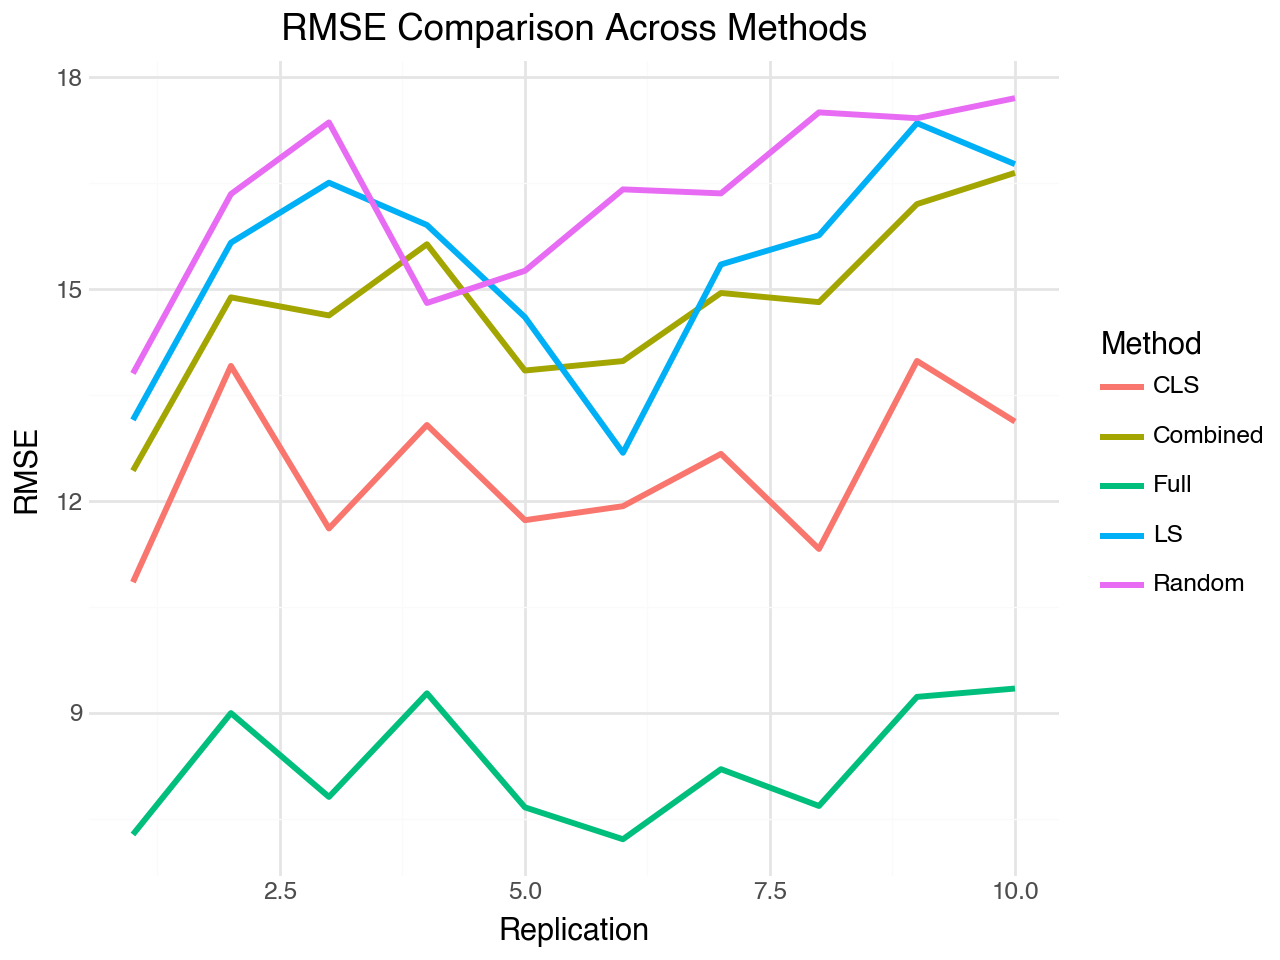

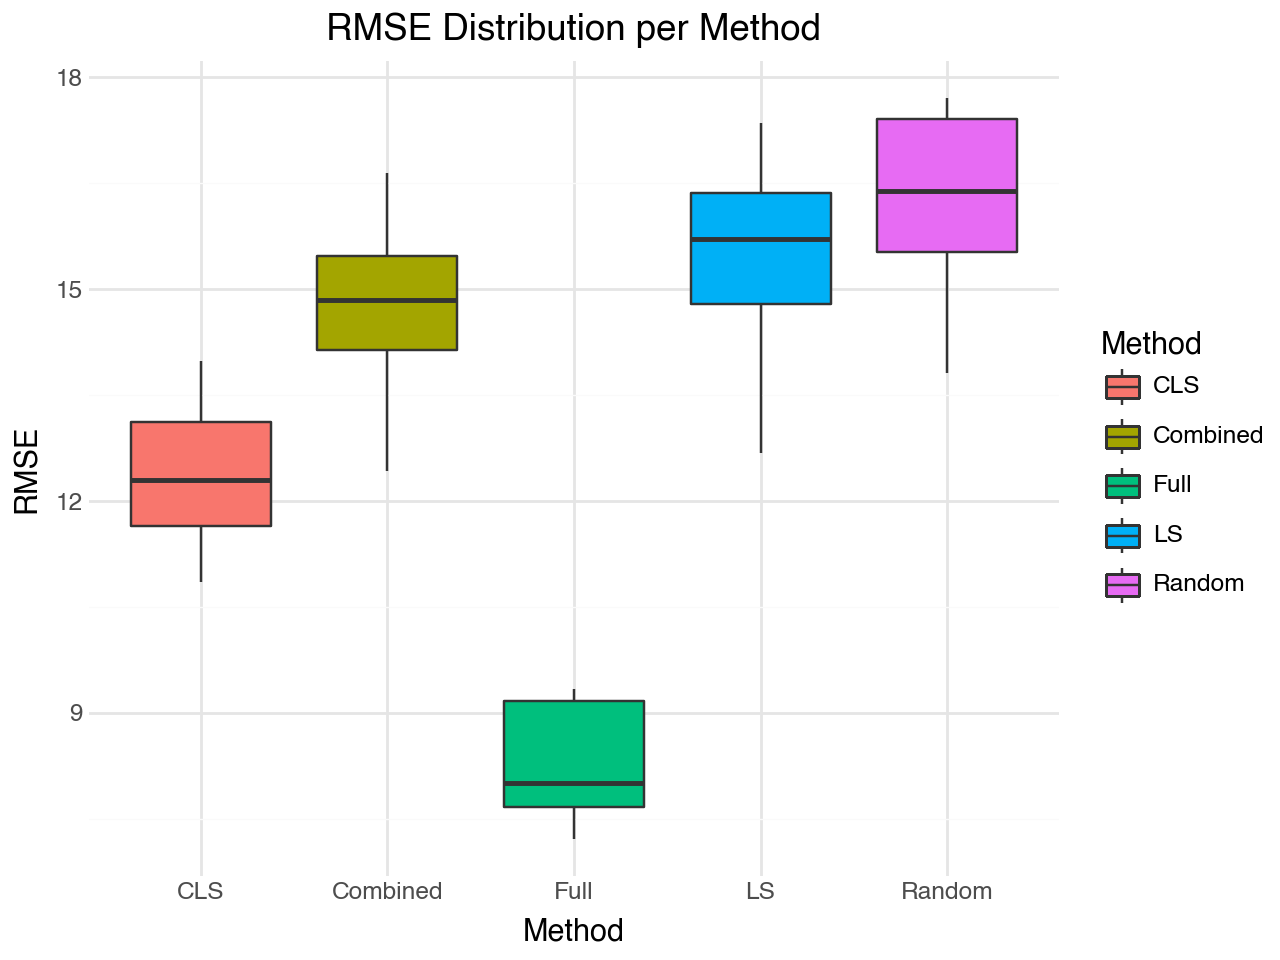

In [219]:
#==============================================================================================
# RMSE Plotting: Building a Line Chart over the RMSE values by Replication
#==============================================================================================

# Index = Replication
rmse_df["Replication"] = np.arange(1, len(rmse_ls) + 1)

# crete long format
rmse_long = rmse_df.melt(
    id_vars="Replication",
    var_name="Method",
    value_name="RMSE"
)
p_line = (
    ggplot(rmse_long, aes(x="Replication", y="RMSE", color="Method"))
    + geom_line(size=1.2)
    + theme_minimal()
    + labs(
        title="RMSE Comparison Across Methods",
        x="Replication",
        y="RMSE"
    )
)
display(p_line)

# Boxplot pro Methode
p_box = (
    ggplot(rmse_long, aes(x="Method", y="RMSE", fill="Method"))
    + geom_boxplot()
    + theme_minimal()
    + labs(
        title="RMSE Distribution per Method",
        x="Method",
        y="RMSE"
    )
)
display(p_box)


In [199]:
#### LS Investigation
beta = beta_train[0]
beta = beta.to_numpy().reshape(-1)
ls = column_ls[0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(ls)[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} LS-Spalten sind {len(hits)} korrekt identifiziert")

[430 869 384 435 104 816 604 508 944 766 805 222 815 699 381  75  17  90
 207 107 659 594 874 412 184 460 366 794  14 340 840 681 335 943 701 178
 749 926 596 850 584 687 323 609  60  72  33 802 841 479  11 316 247 225
 353 101 294 709  67 144 403 500 358 288  70 900 495 418 117 469 645 620
 492 875 646 903 669 382 873 704 883 724 905 567 203 744 625 834 374 526
 715 671 309 888 545 563 898 972 734 315 554 120  20 512 166  89 859 289
 939 290 419 756 254 468 411 269 923 657 565 318 909 877   7 692 741 847
 436  92 228 982 496 913 736 544 983 580 299 402 638 878  81 431 311 675
  52 662 463 226 743 762 467 896 477 137 326 343 649 154 865 368  62 963
 856 361 640 810 453 551 439 933 745 474  32 232 870 267 739 357 747  30
 158 799 606 114 156 417 950 180 272 364 761 320 914 118 770 517 380 953
 181 191 725 139 806 593 491 122  71 987 728 445 655 605 145 843 768 820
 951  85 473 727 686 793 173  91 928 196 674 562 185 634 518 525 271 214
 927 800 628 375 568 973 976 239 106 350 543 312 52

In [200]:
#### CLS Investigation
cls = column_cls[0] 
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(abs(cls))[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(beta[top_c_indices])

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} CLS-Spalten sind {len(hits)} korrekt identifiziert")

tp = top_c_indices
print("Sum |beta| der gefundenen:")
print(np.sum(np.abs(beta[tp])))
print("Sum |beta|:")
print(np.sum(np.abs(beta)))

print("Max |beta| gefunden:")
print(np.max(np.abs(beta[tp])))
print("Max |beta|:")
print(np.max(np.abs(beta)))

[817 297 710 365 143 738 195 141 492 154 749 737 422 125 123 523  95 828
 854 709 161 226 163 949 779 979 712 278 153 599 553 750 274 506 614  39
 774 722 394 978  90 585 820 186 483 857 508 883 783 138 466 304 616 908
 584 947 587 638 613 572 805 113 666 160 690 922 758 654 591 588 486 991
 554  93 498 249 269  50 211 356 647 898 746 128 627 149 439  73   4 183
 648 830 691 333 778 385 525 198 747 657 983 534 215 311 827 512 555 400
 595   3 137 129 802 332 181 862 254 871 565 731 724 277 761 500 740 318
 376 546 548  46 328 912 759   1 300 484 620 467  15 168 192 115 601  38
 754 677 454 491 633 636 813 775 930 935 730 851  66 960 380 295  60 447
 347 968 872 290  44 397 257 361 693 427  98 603 337 642 246 708 426 927
  35 560 792 945 353 373 251 437 501 705 393 679 100 680 406  23 204 567
  13  12 441 619 202 698 645 923  16 877 430 329 821 897  58 227 219 936
 193 829 540 575 131 824 253 688 327 809 224 873 419 191 741 990 602 630
 869 175  26  19 596 735 250 926 415 569 388 442 71

In [190]:
#### CS Investigation
cs = column_cs[0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(abs(cs))[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} CS-Spalten sind {len(hits)} korrekt identifiziert")

[ 77 769 134 188 184  68 146 696 703 787 298 203 105 599 958 538 261 979
 807 733 207  89 241 243  99 597 555 797 104  21 678 118 475 150 947  64
  75 371 310 340 967 867 629 165 242 279 632 102 598 768 116 729 694 737
 287 948 826 472 892 405 408 819 570 745 513 974 589 572 612 523 211 707
 888 392 532 177 230 288  41 363 510 952  62 573 372 145 366 364 484 468
 609 675 594 606 286 656 535 280  48  31 416 338 852 782   5 431 421  76
 113 838 552 988 921 167 547  54 443 106 677 682 600 440 825 526 354 563
 367 357  37 293 284 697 903 748  56 666 583 518 756  28  40 717 604 605
  53  27 683  84  63 750  10 778 868 222 297 808 168 409 281 878 670 685
 882 433 235 858 359 887  15 245 529 117 317 699 306 608 172 836 276 955
 590 398 631 247 937 414 831 147 610 228 695 911 201 578 505 307 663 445
  45 244 847 266 196 413 320 621 209 515 174 108 263 766 949 577 457 404
 559 548 812 674  73   1 773 679 713 330  95 543 669 643 158 517 916 527
 183  14 673  55 524 460 374 828 302 964 830 860 90

In [191]:
#### RS Investigation
rs = column_rs[0]  
c = int(np.ceil(k * np.log(k)))
top_c_indices = np.argsort(rs)[-c:]
print(top_c_indices)
true_nonzero = np.where(beta != 0.0)[0]
print(true_nonzero)

hits = np.intersect1d(top_c_indices, true_nonzero)
print(f"Von den Top-{c} LS-Spalten sind {len(hits)} korrekt identifiziert")

[423 568 445 569  62 343 627 587 680 434 789 231 234 848 939 347 248 746
 661  43 461 462 534 471 775 799  54  51 605 878 555 611 818 621 304  48
 206 293 205 526 465 783 641 329  28 737 800 954 314 898 440 148 474 812
 683 564 383 529 865 331 185 414 224 136 853 678  94  40 585 751 221 593
 623   3 704 235 333  42 949 244 740 712 631 385 455 401 638  98 145 159
 292 140 203  18 595 565 350 774 202 867 607 334  16 868 523 201 370 187
  37 820 741  65 115 313 549 153 889 933 433 857 628 243 255 470 505 456
 409 971 566  25 521 827 176 444 412 927 380 903 716 904 367 369 760 540
 200 863 575 420  91 982 149 431 988 404 121 215 429 823 870 893 442 507
  29  78 276  47 987 348 166 220 975  41 372 330 677 957 551 142 832   0
  66  87 862 473 487 207 528  56  89 965 340 793 118  24 596 960 218 952
 296 671 416 614 622 450 516 268 922 119 835 307 871 535 655 315 536 973
 947 437 929 101 956 326 312 640 739 232 291 786 332 688 663 410 696 906
 508 896 584 408 344 532 958 106  67 480  74 859 11